<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/gallery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Gallery of Astronomical Objects**

In [ ]:
!pip install astropy astroquery requests reproject -q
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad
from astropy import coordinates
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from astropy import coordinates as coords
from reproject import reproject_interp
import matplotlib.pyplot as plt

In [ ]:
# Define object
object_name = 'M104'

#### **Get skycoordinates of astronomical object**

In [ ]:
# Get and set skycoordinates of object
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord

skyobject = Simbad.query_object(object_name)
ra_hms = skyobject['RA'][0]
dec_dms = skyobject['DEC'][0]
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
print(skyobject)
print("\nCoordinates:")
print("RA (h:m:s):", ra_hms)
print("DEC (d:m:s):", dec_dms)

MAIN_ID       RA           DEC      RA_PREC ... COO_WAVELENGTH     COO_BIBCODE     SCRIPT_NUMBER_ID
           "h:m:s"       "d:m:s"            ...                                                    
------- ------------- ------------- ------- ... -------------- ------------------- ----------------
  M 104 12 39 59.4318 -11 37 22.996      12 ...              R 2020A&A...644A.159C                1

Coordinates:
RA (h:m:s): 12 39 59.4318
DEC (d:m:s): -11 37 22.996


#### **Code for Multi-Wavelength Composite (with MAST)**

In [ ]:
# Code for Multi-Wavelength Composite (with MAST)

from astroquery.mast import Observations
from astropy.visualization import make_lupton_rgb

# Function to create composite image
def process_hst_images(params):
    # Search for observations
    obs_table = Observations.query_region(params.coords, radius=params.search_radius)

    # Filter for HST observations with specific filters
    hst_obs = obs_table[obs_table['instrument_name'] == params.instrument]

    # Get observations for each filter
    filter_data = {}
    for color, filter_name in params.rgb_filters.items():
        filter_data[color] = hst_obs[hst_obs['filters'] == filter_name]
        print(f"{filter_name}: {len(filter_data[color])} observations")

    # Check if we have all required filters
    if all(len(data) > 0 for data in filter_data.values()):
        print("\nDownloading data products...")

        # Download and process each filter
        hdus = {}
        for color, observations in filter_data.items():
            products = Observations.get_product_list(observations[0]['obsid'])
            files = Observations.download_products(products[products['productSubGroupDescription'] == 'DRZ'])
            hdus[color] = fits.open(files['Local Path'][0])[1]

        # Reproject images to match the red channel
        print("Aligning images...")
        aligned_data = {
            'red': hdus['red'].data,
            'green': reproject_interp(hdus['green'], hdus['red'].header)[0],
            'blue': reproject_interp(hdus['blue'], hdus['red'].header)[0]
        }

        # Normalize the data
        print("Normalizing data...")
        normalized_data = {color: normalize(data) for color, data in aligned_data.items()}

        # Create RGB image
        print("Creating color composite...")
        rgb = make_lupton_rgb(
            normalized_data['red'],
            normalized_data['green'],
            normalized_data['blue'],
            Q=params.rgb_params['Q'],
            stretch=params.rgb_params['stretch']
        )

        # Plot
        plt.figure(figsize=params.figure_size)
        plt.imshow(rgb, origin='lower')
        plt.title(f'{params.object_name} - HST {params.instrument} Composite')
        plt.axis('off')
        plt.show()
    else:
        print("Could not find all required filter observations")

def normalize(arr):
    """Normalize array data"""
    arr = np.nan_to_num(arr, 0)  # Replace NaN with 0
    return arr / np.percentile(arr[arr > 0], 99)

#### **Automated Query and Visualization**

In [ ]:
# Check possible filter combinations for an object (HST observations)

from astroquery.mast import Observations

def get_filter_combinations(coords, radius=0.2*u.deg):
    obs_table = Observations.query_region(coords, radius=radius)
    hst_obs = obs_table[obs_table['obs_collection'] == 'HST']

    # Create instrument-filter dictionary with DRZ products only
    instruments = {}
    for obs in hst_obs:
        if not obs['filters']:
            continue

        products = Observations.get_product_list(obs['obsid'])
        if not len(products[products['productSubGroupDescription'] == 'DRZ']):
            continue

        if obs['instrument_name'] not in instruments:
            instruments[obs['instrument_name']] = set()
        instruments[obs['instrument_name']].add(obs['filters'])

    print("Possible Filter Combinations:")
    print("=" * 50)

    for instrument, filters in instruments.items():
        filters = list(filters)
        if len(filters) >= 3:
            print(f"\n{instrument} possible combinations:")
            print("Suggested RGB combinations:")

            # Group filters
            uv = [f for f in filters if 'F' in f and int(f[1:4]) < 400]
            optical = [f for f in filters if 'F' in f and 400 <= int(f[1:4]) <= 700]
            ir = [f for f in filters if 'F' in f and int(f[1:4]) > 700]

            if len(optical) >= 3:
                print(f"- Natural colors: {sorted(optical[:3])}")
            if uv and optical and ir:
                print(f"- Extended range: {sorted([uv[0], optical[0], ir[0]])}")

coords = coord
get_filter_combinations(coords)

Possible Filter Combinations:

ACS/WFC possible combinations:
Suggested RGB combinations:
- Natural colors: ['F435W', 'F555W', 'F606W']

WFPC2/PC possible combinations:
Suggested RGB combinations:
- Natural colors: ['F502N', 'F606W', 'F656N']
- Extended range: ['F255W', 'F606W', 'F814W']

WFC3/IR possible combinations:
Suggested RGB combinations:

WFC3/UVIS possible combinations:
Suggested RGB combinations:
- Natural colors: ['F555W', 'F606W', 'F673N']
- Extended range: ['F225W', 'F606W', 'F814W']

ACS/HRC possible combinations:
Suggested RGB combinations:
- Extended range: ['F330W', 'F555W', 'F814W']

NICMOS/NIC2 possible combinations:
Suggested RGB combinations:

NICMOS/NIC3 possible combinations:
Suggested RGB combinations:


F275W: 36 observations
F606W: 77 observations
F814W: 15 observations

Aligning images...
Normalizing data...
Creating color composite...


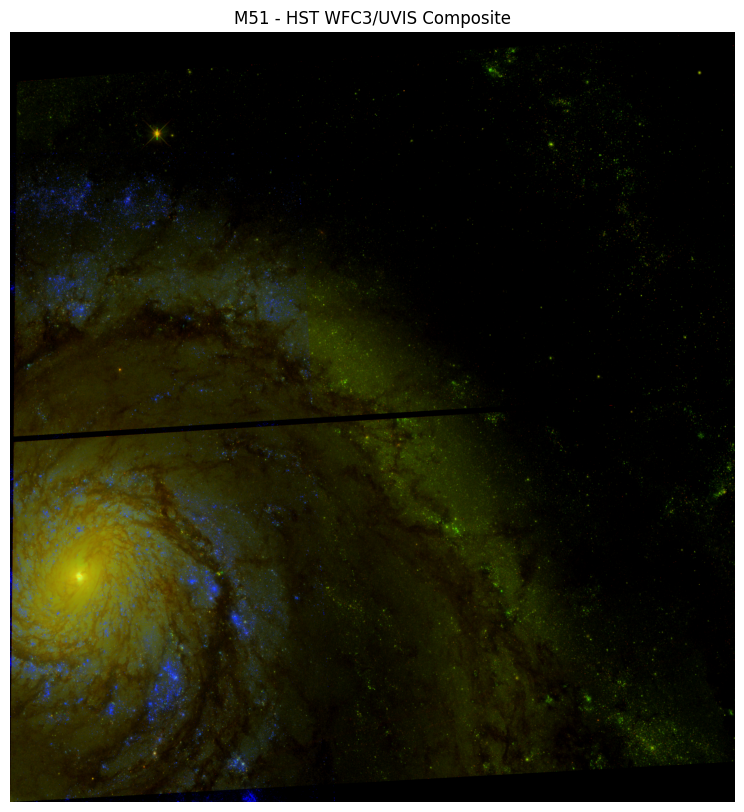

In [ ]:
# Hyperparameters and Run ('object_name' and 'coord' are defined in the beginning, 'rgb_filters' and 'instrument' above)
class ObservationParams:
    def __init__(self):
        # Target coordinates
        self.coords = coord
        self.search_radius = 0.2 * u.deg

        # RGB filter configuration
        self.rgb_filters = {
            'blue': 'F275W',
            'green': 'F606W',
            'red': 'F814W'
        }

        # Instrument configuration
        self.instrument = 'WFC3/UVIS'

        # Image processing parameters
        self.rgb_params = {
            'Q': 10,
            'stretch': 0.5
        }

        # Visualization parameters
        self.figure_size = (10, 10)
        self.object_name = object_name

# Execute image processing
params = ObservationParams()
process_hst_images(params)

#### **Gallery of astronomical objects**

<font color="blue">*Sky coordinates, filters and instrument are known and manually added*

F435W: 107 observations
F555W: 80 observations
F814W: 171 observations

Aligning images...
Normalizing data...
Creating color composite...


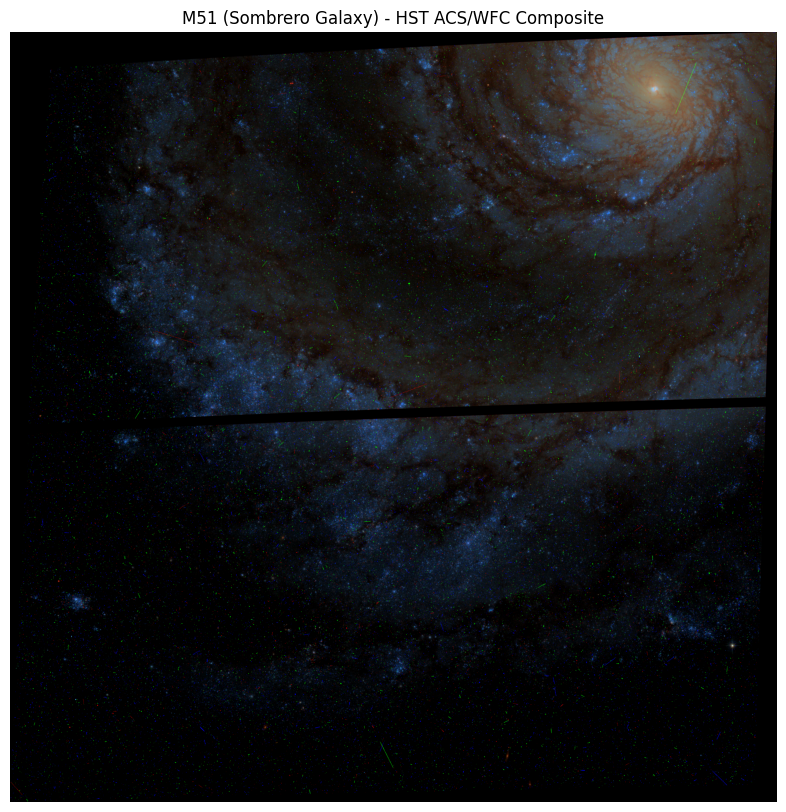

In [ ]:
# Example for M51

class ObservationParams:
    def __init__(self):
        # Target coordinates
        self.coords = SkyCoord('13h29m52.7s +47d11m43s', unit=(u.hourangle, u.deg)) # = coord
        self.search_radius = 0.2 * u.deg

        # RGB filter configuration
        self.rgb_filters = {
            'blue': 'F435W',
            'green': 'F555W',
            'red': 'F814W'
        }

        # Instrument configuration
        self.instrument = 'ACS/WFC'

        # Image processing parameters
        self.rgb_params = {
            'Q': 10,
            'stretch': 0.5
        }

        # Visualization parameters
        self.figure_size = (10, 10)
        self.object_name = 'M51 (Sombrero Galaxy)'

# Execute image processing
params = ObservationParams()
process_hst_images(params)

In [ ]:
# Example for M104

class ObservationParams:
    def __init__(self):
        # Target coordinates
        self.coords = coord
        self.search_radius = 0.2 * u.deg

        # RGB filter configuration
        self.rgb_filters = {
            'blue': 'F275W',
            'green': 'F606W',
            'red': 'F814W'
        }

        # Instrument configuration
        self.instrument = 'WFC3/UVIS'

        # Image processing parameters
        self.rgb_params = {
            'Q': 10,
            'stretch': 0.5
        }

        # Visualization parameters
        self.figure_size = (10, 10)
        self.object_name = 'M 104 (Whirlpool Galaxy)'

# Execute image processing
params = ObservationParams()
process_hst_images(params)

In [ ]:
# Example for M104
class ObservationParams:
    def __init__(self):
        # Target coordinates
        #self.coords = SkyCoord('12h39m59s -11d37m22s', unit=(u.hourangle, u.deg))
        self.coords = SkyCoord('12h39m59.4318s -11d37m22.996s', unit=(u.hourangle, u.deg))
        self.search_radius = 0.2 * u.deg

        # RGB filter configuration
        self.rgb_filters = {
            'blue': 'F275W',
            'green': 'F606W',
            'red': 'F814W'
        }

        # Instrument configuration
        self.instrument = 'WFC3/UVIS'

        # Image processing parameters
        self.rgb_params = {
            'Q': 10,
            'stretch': 0.5
        }

        # Visualization parameters
        self.figure_size = (10, 10)
        self.object_name = object_name

# Execute image processing
params = ObservationParams()
process_hst_images(params)

F275W: 9 observations
F606W: 27 observations
F814W: 22 observations

Aligning images...
Normalizing data...


IndexError: index -1 is out of bounds for axis 0 with size 0